In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

In [2]:
TIER_FILE = Path.cwd().parent / "Dataset" / "cv_review_2.csv"
NMI_MAPPING_FILE = Path.cwd().parent / "Dataset" / "NMI Table.xlsx"
SOLAR_FILE = Path.cwd().parent / "Dataset" / "NMI to weather station.xlsx"

# Load data

In [3]:
tier_df = pd.read_csv(TIER_FILE, index_col='NMI')
tier_df.head()

,classified_tier,cv_judgement,cv_reason
NMI,,,
6103086897,Exclude / Needs Review,reasonable,The exclusion is well supported: the NMI is ma...
6102741362,Exclude / Needs Review,reasonable,Predominantly inactive/zero-heavy series with ...
VAAA001271,Exclude / Needs Review,reasonable,"Mostly inactive with very long zero periods, i..."
6103005867,Tier A - Strong forecasting candidate,reasonable,Strongly patterned and stable load: clear week...
VAAA000182,Tier A - Strong forecasting candidate,reasonable,"Strong, stable recurring load shape with clear..."


In [4]:
nmi_df = pd.read_excel(NMI_MAPPING_FILE, usecols=['NMI', 'Campus', 'Active_window', 'Building Type'])
nmi_df['first_date'] = pd.to_datetime(nmi_df['Active_window'].str.split(' to ').str[0]).dt.date
nmi_df['at_least_2_years'] = nmi_df['first_date'] + pd.DateOffset(years=2) <= pd.to_datetime('2026-03-23')
nmi_df

C:\Users\trizp\AppData\Local\Temp\ipykernel_15560\2442251509.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  nmi_df['first_date'] = pd.to_datetime(nmi_df['Active_window'].str.split(' to ').str[0]).dt.date


,NMI,Campus,Active_window,Building Type,first_date,at_least_2_years
0,6103086897,PAR,NaN,Building - Minimal/Infra- Shed/Whse/Bulk Store...,NaT,False
1,6102000812,BUR,2013/01/01 12:00 AM to 2026/03/23 11:30 PM,Campus,2013-01-01,True
2,6102002302,STH,2013/01/01 12:00 AM to 2026/03/23 11:30 PM,Building - Minimal/Infra- Shed/Whse/Bulk Store...,2013-01-01,True
3,6102005454,PAR,2013/01/01 12:00 AM to 2026/03/23 11:30 PM,Building - Workspace/Teaching/Library,2013-01-01,True
4,6102005592,PAR,2013/01/01 12:00 AM to 2026/03/23 11:30 PM,Building - Workspace/Teaching/Library,2013-01-01,True
...,...,...,...,...,...,...
144,VAAA004066,PAR,2025/01/01 12:00 AM to 2026/03/23 11:30 PM,Building - Workspace/Teaching/Library,2025-01-01,False
145,VCCCAE0035,WER,2013/01/01 12:00 AM to 2026/03/23 11:30 PM,Campus,2013-01-01,True
146,VCCCBC0096,CRE,2013/01/01 12:00 AM to 2026/03/23 11:30 PM,Campus,2013-01-01,True
147,VCCCSC0045,SPT,2013/01/01 12:00 AM to 2026/03/23 11:30 PM,Building - Clinical,2013-01-01,True


In [5]:
new_nmi_df = nmi_df.groupby('NMI')['Building Type'].agg(
                    n_types='nunique',           # Count of unique types
                    types=lambda x: sorted(list(x.unique()))  # List of unique types
                )
new_nmi_df['types'] = new_nmi_df['types'].apply(tuple)
new_nmi_df = pd.merge(new_nmi_df, nmi_df[['NMI','Campus','at_least_2_years']].drop_duplicates().set_index('NMI'), left_index=True, right_index=True, how='left')
new_nmi_df = pd.merge(new_nmi_df, tier_df, left_index=True, right_index=True, how='left')

In [6]:
solar_df = pd.read_excel(SOLAR_FILE, usecols=['NMI','Solar_New'])
solar_df = solar_df.dropna().set_index('NMI')

solar_df = solar_df.groupby('NMI')['Solar_New'].sum().to_frame(name='N_Solar')
solar_df['Solar'] = [1 if x > 0 else 0 for x in solar_df['N_Solar']]


new_nmi_df = pd.merge(new_nmi_df, solar_df[['Solar','N_Solar']], left_index=True, right_index=True, how='left').fillna(0)
new_nmi_df

,n_types,types,Campus,at_least_2_years,classified_tier,cv_judgement,cv_reason,Solar,N_Solar
NMI,,,,,,,,,
6102000812,1,"(Campus,)",BUR,True,Tier B - Usable with caution,questionable,"The Tier B assignment is plausible, but this l...",0.0,0.0
6102002302,1,(Building - Minimal/Infra- Shed/Whse/Bulk Stor...,STH,True,Tier B - Usable with caution,reasonable,"Long, mostly continuous history with very high...",1.0,1.0
6102005454,1,"(Building - Workspace/Teaching/Library,)",PAR,True,Tier A - Strong forecasting candidate,reasonable,"Strong recurring daily/weekly shape, high lag-...",1.0,1.0
6102005592,1,"(Building - Workspace/Teaching/Library,)",PAR,True,Tier B - Usable with caution,reasonable,Strong recurring daily shape with clear weekda...,1.0,1.0
6102009742,1,"(Building - Workspace/Teaching/Library,)",PAR,True,Tier B - Usable with caution,reasonable,Long active history with perfect recent covera...,0.0,0.0
...,...,...,...,...,...,...,...,...,...
VAAA004066,1,"(Building - Workspace/Teaching/Library,)",PAR,False,Tier D - Difficult forecasting candidate,questionable,The Tier D assignment is plausible but borderl...,0.0,0.0
VCCCAE0035,1,"(Campus,)",WER,True,Tier B - Usable with caution,reasonable,"Active with very high coverage, minimal missin...",1.0,1.0
VCCCBC0096,1,"(Campus,)",CRE,True,Tier B - Usable with caution,reasonable,"Active NMI with long history, high recent cove...",1.0,1.0


# Old Tiers

### BY BUILDING TYPE

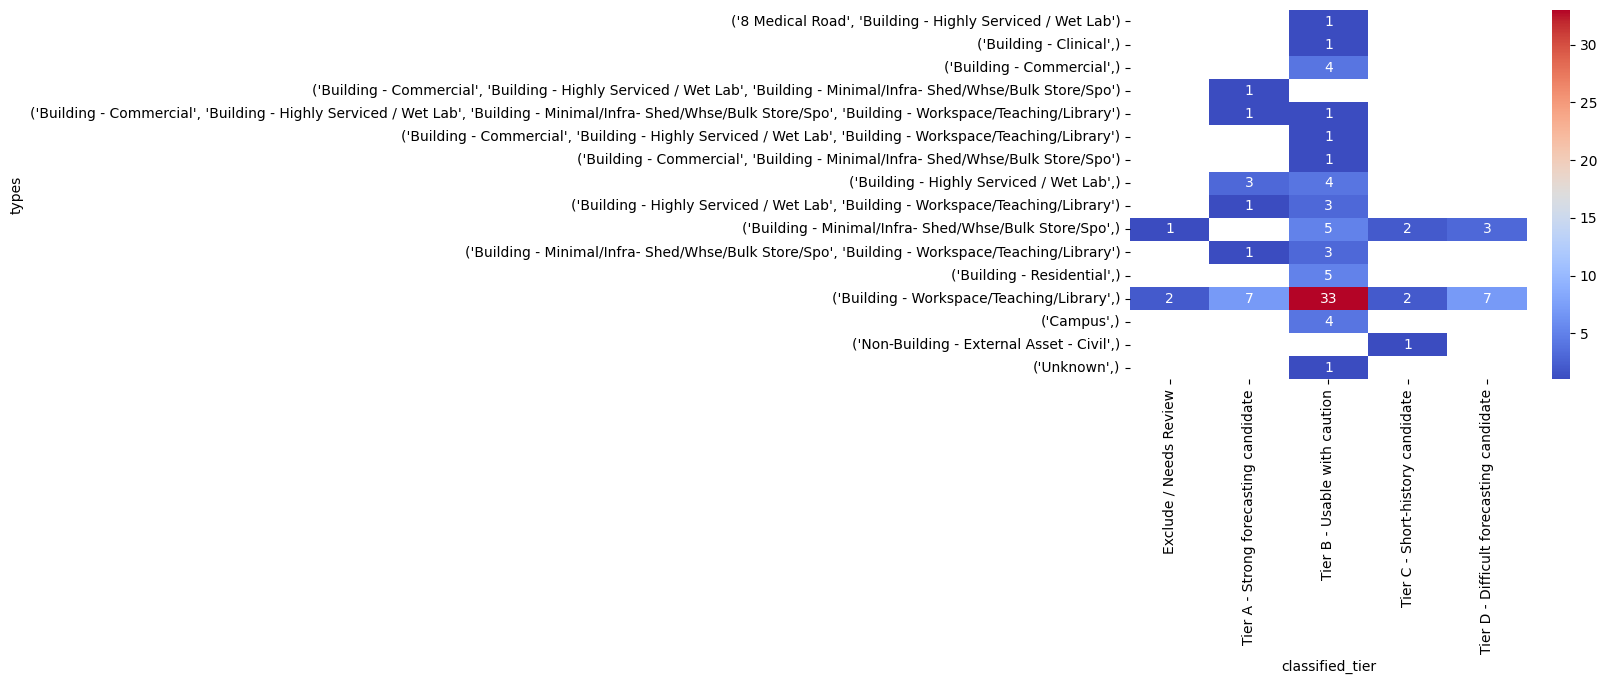

In [7]:
check_df = pd.pivot_table(data=new_nmi_df, index='types', columns='classified_tier', values='cv_judgement', aggfunc='count')
sns.heatmap(check_df, annot=True, cmap='coolwarm')
plt.show()

### BY CAMPUS

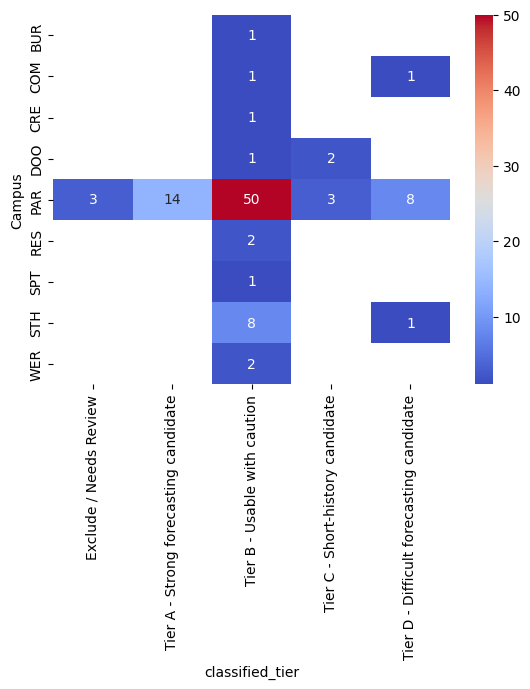

In [8]:
check_df = pd.pivot_table(data=new_nmi_df, index='Campus', columns='classified_tier', values='cv_judgement', aggfunc='count')
sns.heatmap(check_df, annot=True, cmap='coolwarm')
plt.show()

### BY HISTORY

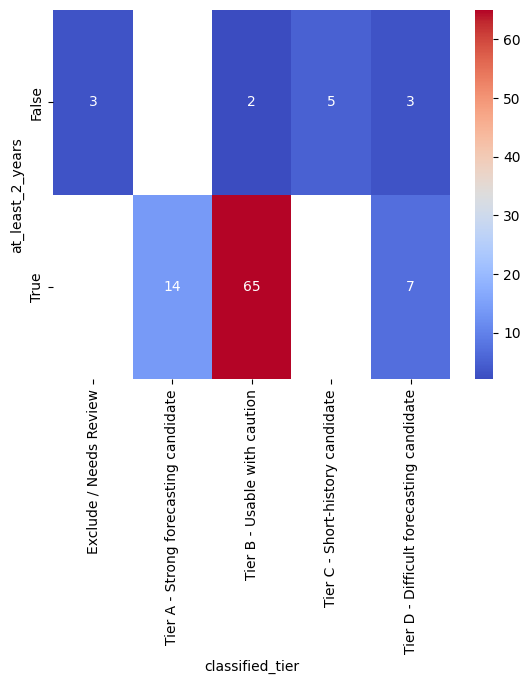

In [9]:
check_df = pd.pivot_table(data=new_nmi_df, index='at_least_2_years', columns='classified_tier', values='cv_judgement', aggfunc='count')
sns.heatmap(check_df, annot=True, cmap='coolwarm')
plt.show()

### BY SOLAR

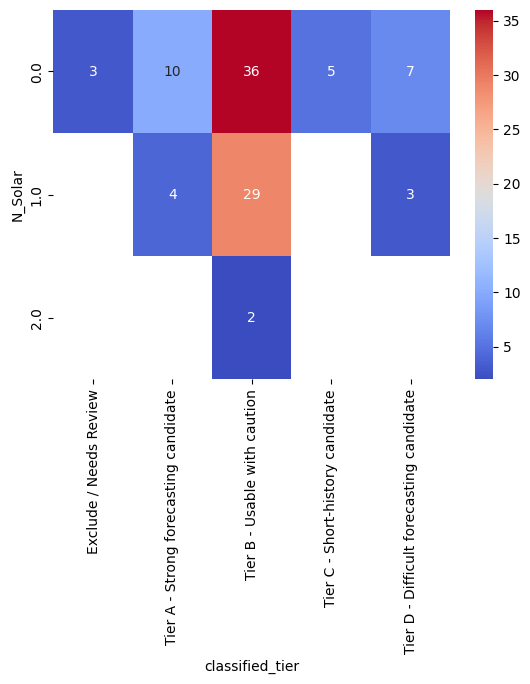

In [10]:
check_df = pd.pivot_table(data=new_nmi_df, index='N_Solar', columns='classified_tier', values='cv_judgement', aggfunc='count')
sns.heatmap(check_df, annot=True, cmap='coolwarm')
plt.show()

In [11]:
newtier = {
    'Tier A - Strong forecasting candidate':'Tier A&B',
    'Tier B - Usable with caution':'Tier A&B',
    'Tier C - Short-history candidate':'Exclude',
    'Tier D - Difficult forecasting candidate':'Tier D',
    'Exclude / Needs Review':'Exclude',
}
new_nmi_df['classified_tier_new'] = [newtier[x] for x in new_nmi_df['classified_tier']]

Tier D
('Building - Minimal/Infra- Shed/Whse/Bulk Store/Spo',)
Active NMI with long history and good coverage, but the load is highly variable with strong spikes, low temporal pattern scores, weak autocorrelation, and a near-useless baseline (best WAPE ~0.99). The charts show a clear daily shape, but it is not stable year-to-year and monthly totals vary materially, so Tier D is a fair assignment. Not an Exclude case because data are present and not mostly zero/missing.


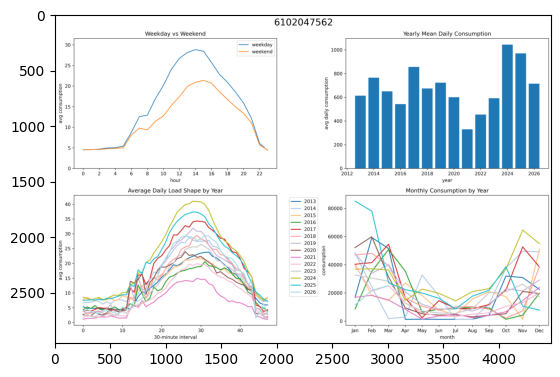

('Building - Workspace/Teaching/Library',)
The D tier is plausible because the series has noticeable volatility and a fairly high outlier rate, with some year-to-year level shifts. However, the load shape is actually quite structured: strong weekday intraday pattern, clear weekly effect, and a strong lag-336 correlation with a good lag-based baseline (WAPE ~0.175). That looks more like a Tier B candidate than Tier D. The main caveat is the limited historical window/low history score, so Tier D seems a bit too harsh rather than clearly wrong.


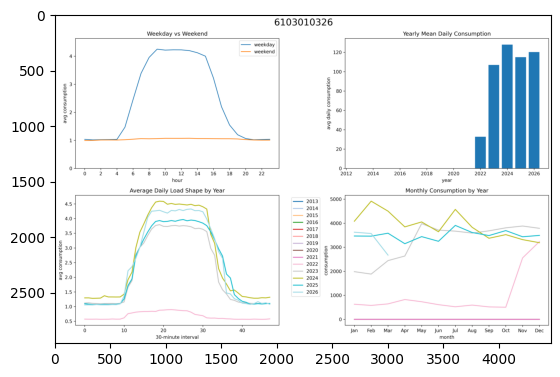

('Building - Minimal/Infra- Shed/Whse/Bulk Store/Spo',)
The D assignment is plausible but borderline. The series is mostly active with high coverage, low missingness, modest zero rate, and a clear recurring daily shape plus weekday/weekend separation, so it is not visually a classic difficult/noisy case. However, the pattern is only moderately stable, year-to-year shapes shift noticeably, monthly volumes vary, and the temporal pattern/seasonality metrics are weak with a relatively high baseline WAPE (~0.38). This looks more like Tier B/D borderline, with Tier B - Usable with caution or possibly Tier C depending on the intended history emphasis, rather than a firm Tier D.


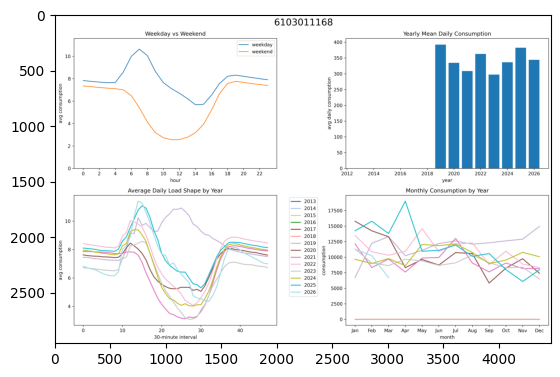

('Building - Minimal/Infra- Shed/Whse/Bulk Store/Spo',)
Active meter with ~6.7 years of history, excellent coverage, and very low missing/zero rates. The charts show a clear recurring daily shape and some weekday/weekend structure, plus a usable lag-336 baseline (WAPE ~0.23). However, the series has noticeable year-to-year level shifts, intermittent spikes, and moderate volatility, so it is not a strong Tier A/B candidate. Tier D is a bit harsh; Tier B (or possibly B/C boundary) looks more plausible than D.


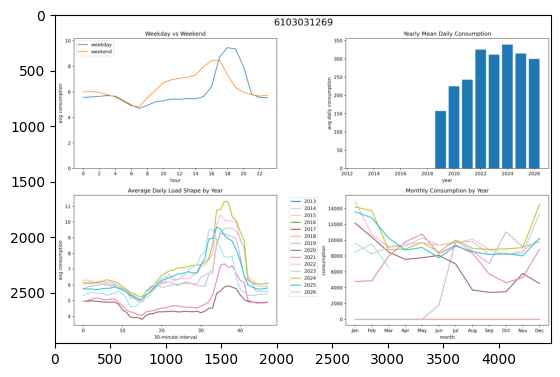

('Building - Workspace/Teaching/Library',)
The D tier is plausible because the series is quite unstable year-to-year, with high outlier rate, large swings in annual totals, and only weak daily/weekly pattern strength. However, it is not a clear difficult/noisy case: the load shape is fairly recurring, weekday/weekend profiles are consistent, lag correlations are decent, and recent coverage is excellent. This looks more like a borderline Tier B/C candidate than a true Tier D, so the assigned tier seems conservative.


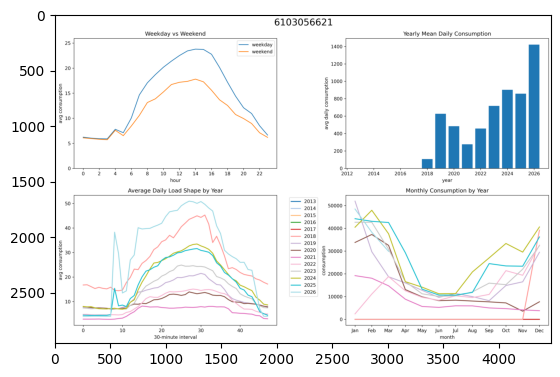

('Building - Workspace/Teaching/Library',)
The D tier is plausible because the series has visible instability and some data-quality caveats: a long early zero period, nontrivial outliers, and only moderate temporal pattern strength. However, the main load shape is fairly consistent across years, weekday/weekend curves are stable, lag-48 correlation is strong, and recent coverage is complete. This looks more like a Tier B/C candidate than a true Tier D, so the assigned tier seems a bit too pessimistic.


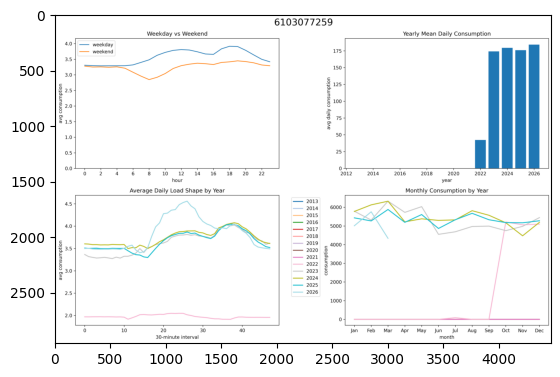

('Building - Workspace/Teaching/Library',)
The D rating is plausible because the series has noticeable instability, a long zero run around early 2023, and some elevated volatility/spikes. However, the load is clearly active, well-covered, and strongly patterned: strong daily/weekly structure, good lag correlations, and a stable recurring diurnal shape across years. This looks more like Tier B with caution, or possibly Tier C if the short effective backtest/history is the main concern, rather than a true difficult/noisy D case.


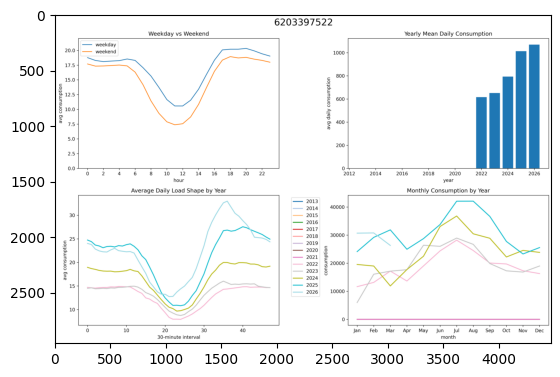

In [12]:
for tier in sorted(new_nmi_df['classified_tier_new'].unique())[-1:]:
    print(tier)
    
    for nmi in new_nmi_df[(new_nmi_df['at_least_2_years']) & (new_nmi_df['classified_tier_new']==tier)].index:
        print(new_nmi_df.loc[nmi, 'types'])
        print(new_nmi_df.loc[nmi, 'cv_reason'])
        try:
            for graph in ['Deep Dive']:
                img = mpimg.imread(Path.cwd().parent / "Dataset" / "EDA Results" / f"{nmi} {graph}.png")
                plt.imshow(img)
                plt.show()
        except:
            print(f'No graph: {nmi}')

# New Categorization

1. Inactive or less than 2 years (not enough history; not used for training)
2. With Solar (low/medium consumption during midday)
3. Workspace/Teaching/Library except Melbourne Connect (typical bell curve load shape)
4. Wet Lab (minimal weekday/weekend difference and/or almost flat consumption across months)
5. Others (odd peaks during the day)

In [13]:
nmi_cat_df = new_nmi_df['at_least_2_years'].to_frame(name='at_least_2_years')
nmi_cat_df['Category'] = [None if x else 'Cat1_PoorHistory' for x in nmi_cat_df['at_least_2_years']]
del nmi_cat_df['at_least_2_years']
nmi_cat_df['Category'].value_counts()

Category
Cat1_PoorHistory    13
Name: count, dtype: int64

In [14]:
nmi_cat_df['Category'] = ['Cat2_WithSolar' if ((nmi_cat_df.loc[nmi,'Category']!=nmi_cat_df.loc[nmi,'Category']) & (new_nmi_df.loc[nmi,'Solar']>0)) else nmi_cat_df.loc[nmi,'Category'] for nmi in nmi_cat_df.index]
nmi_cat_df.value_counts()

Category        
Cat2_WithSolar      38
Cat1_PoorHistory    13
Name: count, dtype: int64

In [15]:
MELBOURNE_CONNECT_NMI = '6103065121'
nmi_cat_df['Category'] = ['Cat3_WorkspaceTeachingLibrary' if
                          ((nmi_cat_df.loc[nmi,'Category']!=nmi_cat_df.loc[nmi,'Category']) & 
                           (nmi!=MELBOURNE_CONNECT_NMI) & 
                           (new_nmi_df.loc[nmi,'types']==('Building - Workspace/Teaching/Library',)))
                            else nmi_cat_df.loc[nmi,'Category'] for nmi in nmi_cat_df.index]
nmi_cat_df.value_counts()

Category                     
Cat2_WithSolar                   38
Cat3_WorkspaceTeachingLibrary    26
Cat1_PoorHistory                 13
Name: count, dtype: int64

PAR
('Building - Workspace/Teaching/Library',)


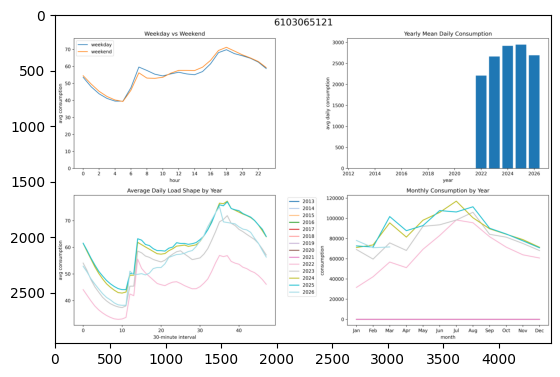

In [16]:
nmi = MELBOURNE_CONNECT_NMI
print(new_nmi_df.loc[nmi, 'Campus'])    
print(new_nmi_df.loc[nmi, 'types'])

try:
    for graph in ['Deep Dive']:
        img = mpimg.imread(Path.cwd().parent / "Dataset" / "EDA Results" / f"{nmi} {graph}.png")
        plt.imshow(img)
        plt.show()
except:
    print(f'No graph: {nmi}')

In [17]:
nmi_cat_df['Category'] = ['Cat4_WetLab' if
                          ((nmi_cat_df.loc[nmi,'Category']!=nmi_cat_df.loc[nmi,'Category']) & 
                           (any('Wet Lab' in tup for tup in new_nmi_df.loc[nmi, 'types'])))
                           else nmi_cat_df.loc[nmi,'Category'] for nmi in nmi_cat_df.index]
nmi_cat_df.value_counts()

Category                     
Cat2_WithSolar                   38
Cat3_WorkspaceTeachingLibrary    26
Cat1_PoorHistory                 13
Cat4_WetLab                      11
Name: count, dtype: int64

In [18]:
nmi_cat_df['Category'] = ['Cat5_OtherBuildingTypes' if
                          nmi_cat_df.loc[nmi,'Category']!=nmi_cat_df.loc[nmi,'Category']
                          else nmi_cat_df.loc[nmi,'Category'] for nmi in nmi_cat_df.index]
nmi_cat_df.value_counts()

Category                     
Cat2_WithSolar                   38
Cat3_WorkspaceTeachingLibrary    26
Cat1_PoorHistory                 13
Cat5_OtherBuildingTypes          11
Cat4_WetLab                      11
Name: count, dtype: int64

In [19]:
new_nmi_df[nmi_cat_df['Category']=='Cat5_OtherBuildingTypes']['types'].value_counts()

types
(Building - Residential,)                                4
(Building - Commercial,)                                 3
(Campus,)                                                1
(Building - Minimal/Infra- Shed/Whse/Bulk Store/Spo,)    1
(Building - Workspace/Teaching/Library,)                 1
(Unknown,)                                               1
Name: count, dtype: int64

In [20]:
desc = {'Cat1_PoorHistory':'inactive or less than 2 years active',
        'Cat2_WithSolar':'low to medium consumption during midday (duck curve)',
        'Cat3_WorkspaceTeachingLibrary':'high during day time (bell curve)',
        'Cat4_WetLab':'minimal weekday-weekend difference; no monthly seasonality',
        'Cat5_OtherBuildingTypes':'odd peak times within the day'
}

act = {'Cat1_PoorHistory':'excluded in training the model',
        'Cat2_WithSolar':'',
        'Cat3_WorkspaceTeachingLibrary':'',
        'Cat4_WetLab':'',
        'Cat5_OtherBuildingTypes':''
}

nmi_cat_df['Description'] = [desc[cat] for cat in nmi_cat_df['Category']]
nmi_cat_df['Action'] = [act[cat] for cat in nmi_cat_df['Category']]
nmi_cat_df

,Category,Description,Action
NMI,,,
6102000812,Cat5_OtherBuildingTypes,odd peak times within the day,
6102002302,Cat2_WithSolar,low to medium consumption during midday (duck ...,
6102005454,Cat2_WithSolar,low to medium consumption during midday (duck ...,
6102005592,Cat2_WithSolar,low to medium consumption during midday (duck ...,
6102009742,Cat3_WorkspaceTeachingLibrary,high during day time (bell curve),
...,...,...,...
VAAA004066,Cat1_PoorHistory,inactive or less than 2 years active,excluded in training the model
VCCCAE0035,Cat2_WithSolar,low to medium consumption during midday (duck ...,
VCCCBC0096,Cat2_WithSolar,low to medium consumption during midday (duck ...,


In [21]:
nmi_cat_df.to_csv(Path.cwd().parent / "Dataset" / "NMI Categories.csv")

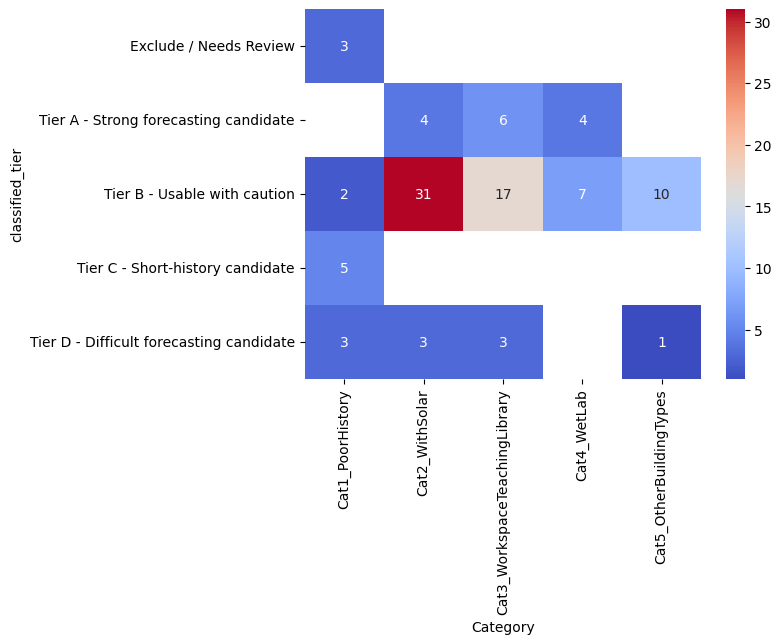

In [22]:
check_df = pd.merge(new_nmi_df,nmi_cat_df, left_index=True, right_index=True, how='outer')
check_df = pd.pivot_table(data=check_df, index='classified_tier', columns='Category', values='Description', aggfunc='count')
sns.heatmap(check_df, annot=True, cmap='coolwarm')
plt.show()